# 特定検診に行く人の割合が高い県は生産性が高い
- **目的変数**: 県民一人あたり県内総生産[千円/人]
- **主説明変数**: 特定健診等受診率
- **その他説明変数**: 特定保健指導実施率・後発医薬品使用率・受診勧奨率・対象者減少率

## 保険料率のインセンティブに持ちいられる指標のうち、特定検診 が 県民一人あたり県内総生産 との有意な正の相関がある


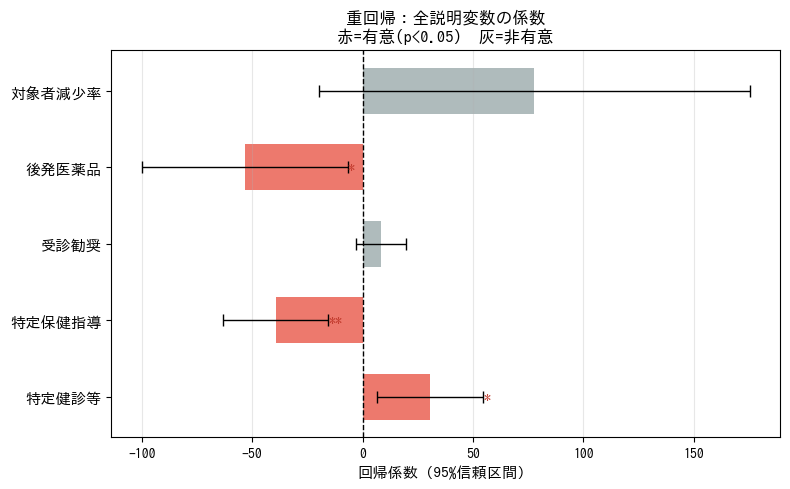


【重回帰結果】
  R²: 0.1353
  Adj. R²: 0.1033

各説明変数の係数・p値:
             係数      p値
特定健診等   30.7104  0.0123
特定保健指導 -39.2895  0.0014
受診勧奨     8.3329  0.1545
後発医薬品  -53.4271  0.0251
対象者減少率  77.7929  0.1172
                            OLS Regression Results                            
Dep. Variable:     県民一人あたり県内総生産[千円/人]   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     4.225
Date:                Sat, 27 Jun 2026   Prob (F-statistic):            0.00134
Time:                        09:40:58   Log-Likelihood:                -1133.2
No. Observations:                 141   AIC:                             2278.
Df Residuals:                     135   BIC:                             2296.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
            

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定（IPAGothic）
matplotlib.rcParams['font.family'] = 'IPAGothic'
plt.rcParams['axes.unicode_minus'] = False

# データ読み込み（v2: 病床数・地域差指数・県民所得を追加）
df = pd.read_csv('../data/分析用データ.tsv', sep='\t')
df = df.dropna()

# データ表示
# print(f"カラム ({len(df.columns)}個): {list(df.columns)}")
# print(f"データ件数: {len(df)} 行")
# print(f"年度: {sorted(df['年度'].unique())}")
# df.head()


## 重回帰モデル（全パラメーター）
feature_cols = [
    '特定健診等',       # 予防・健診系 KPI
    '特定保健指導',
    '受診勧奨',
    '後発医薬品',
    '対象者減少率',
    # '調整前所要保険料率',
    # '年齢調整',
]

X_multi = sm.add_constant(df[feature_cols])
y = df['県民一人あたり県内総生産[千円/人]']

model_multi = sm.OLS(y, X_multi).fit()


## 係数プロット（全パラメーター重回帰）
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

# 左：係数と95%信頼区間（有意なものを赤で）
coefs = model_multi.params[1:]
conf = model_multi.conf_int().iloc[1:]
pvals = model_multi.pvalues[1:]
colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in pvals]

ax = axes
y_pos = range(len(coefs))
ax.barh(y_pos, coefs.values, color=colors, alpha=0.75, height=0.6)
ax.errorbar(coefs.values, y_pos,
            xerr=[coefs.values - conf[0].values, conf[1].values - coefs.values],
            fmt='none', color='black', capsize=4, linewidth=1)
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(coefs.index, fontsize=11)
ax.set_xlabel('回帰係数（95%信頼区間）', fontsize=11)
ax.set_title('重回帰：全説明変数の係数\n赤=有意(p<0.05)  灰=非有意', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)

# p値アノテーション
for i, (c, p) in enumerate(zip(coefs.values, pvals)):
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    if sig:
        ax.text(c + (conf[1].iloc[i] - c) + 0.005, i, sig,
                va='center', fontsize=10, color='#c0392b')

# 右：実測値 vs 予測値
# y_pred_multi = model_multi.fittedvalues
# ax2 = axes[1]
# ax2.scatter(y, y_pred_multi, alpha=0.5, color='steelblue', s=40)
# lims = [min(y.min(), y_pred_multi.min()) - 0.05,
#         max(y.max(), y_pred_multi.max()) + 0.05]
# ax2.plot(lims, lims, 'r--', linewidth=1.5, label='完全予測線')
# ax2.set_xlabel('実測値（県民一人あたり県内総生産[千円/人]）', fontsize=11)
# ax2.set_ylabel('予測値', fontsize=11)
# ax2.set_title(f'実測値 vs 予測値\nR²={model_multi.rsquared:.3f}  Adj.R²={model_multi.rsquared_adj:.3f}', fontsize=12)
# ax2.legend(fontsize=10)
# ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n【重回帰結果】")
print(f"  R²: {model_multi.rsquared:.4f}")
print(f"  Adj. R²: {model_multi.rsquared_adj:.4f}")
print("\n各説明変数の係数・p値:")
print(pd.DataFrame({
    '係数': model_multi.params[feature_cols],
    'p値': model_multi.pvalues[feature_cols],
}).round(4))

print(model_multi.summary())

## 特定検診受診率が1%増加すれば、県民一人あたり県内総生産が8900円増加する傾向がある

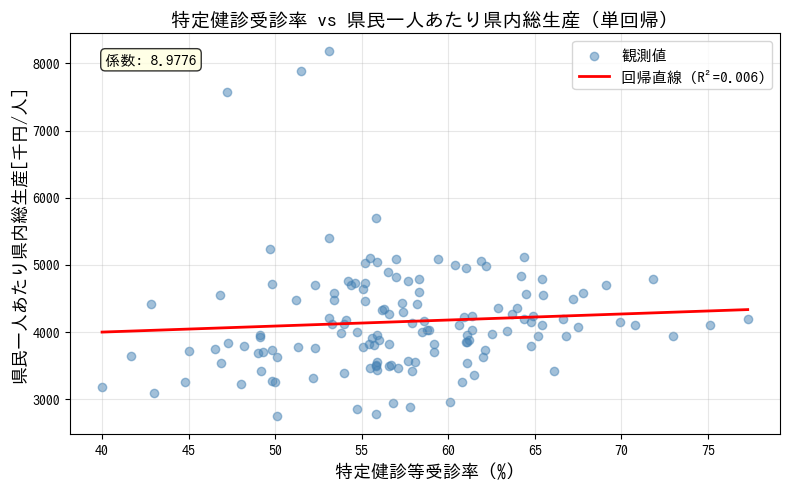


【単回帰結果】
  回帰係数: 8.9776
  p値: 0.3738  有意でない
  R²: 0.0057
                            OLS Regression Results                            
Dep. Variable:     県民一人あたり県内総生産[千円/人]   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7959
Date:                Sat, 27 Jun 2026   Prob (F-statistic):              0.374
Time:                        09:40:58   Log-Likelihood:                -1143.1
No. Observations:                 141   AIC:                             2290.
Df Residuals:                     139   BIC:                             2296.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [2]:
## 単回帰：特定健診等 → 県民一人あたり県内総生産
X_simple = sm.add_constant(df['特定健診等'])
y = df['県民一人あたり県内総生産[千円/人]']

model_simple = sm.OLS(y, X_simple).fit()


## 散布図（単回帰）
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['特定健診等'], df['県民一人あたり県内総生産[千円/人]'], alpha=0.5, color='steelblue', label='観測値')

x_range = np.linspace(df['特定健診等'].min(), df['特定健診等'].max(), 100)
x_pred = sm.add_constant(x_range)
y_pred = model_simple.predict(x_pred)
ax.plot(x_range, y_pred, color='red', linewidth=2, label=f'回帰直線 (R²={model_simple.rsquared:.3f})')

ax.set_xlabel('特定健診等受診率 (%)', fontsize=13)
ax.set_ylabel('県民一人あたり県内総生産[千円/人]', fontsize=13)
ax.set_title('特定健診受診率 vs 県民一人あたり県内総生産（単回帰）', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

coef = model_simple.params['特定健診等']
pval = model_simple.pvalues['特定健診等']
# ax.text(0.05, 0.95, f'係数: {coef:.4f}  p値: {pval:.4f}',
#         transform=ax.transAxes, fontsize=11, verticalalignment='top',
#         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.text(0.05, 0.95, f'係数: {coef:.4f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n【単回帰結果】")
print(f"  回帰係数: {coef:.4f}")
print(f"  p値: {pval:.4f}  {'*** 有意 (1%)' if pval<0.01 else '** 有意 (5%)' if pval<0.05 else '* 有意 (10%)' if pval<0.1 else '有意でない'}")
print(f"  R²: {model_simple.rsquared:.4f}")

print(model_simple.summary())

# 特定検診受診率が1%に対する県民一人あたり県内総生産の傾きは+20,000[円/人/年]であり、特定検診受診率と県民一人あたり地方県内総生産は有意な正の相関がある※
※東京を除いた場合

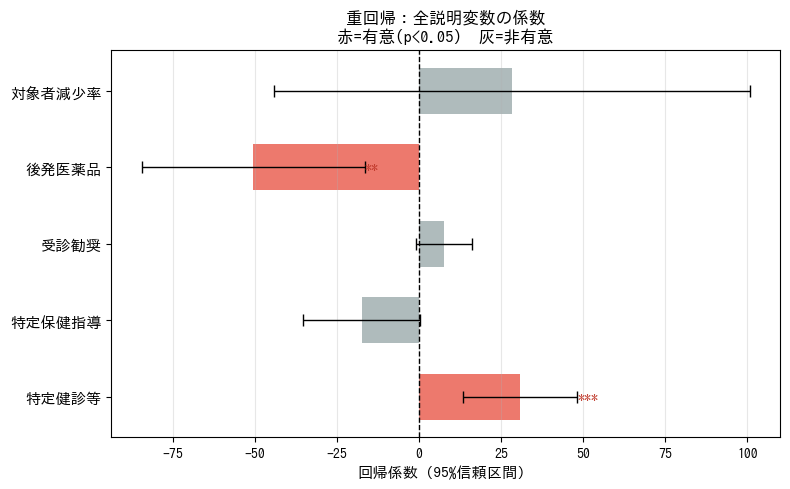


【重回帰結果】
  R²: 0.1580
  Adj. R²: 0.1261

各説明変数の係数・p値:
             係数      p値
特定健診等   30.7735  0.0007
特定保健指導 -17.4459  0.0549
受診勧奨     7.6400  0.0762
後発医薬品  -50.4832  0.0039
対象者減少率  28.2554  0.4415
                            OLS Regression Results                            
Dep. Variable:     県民一人あたり県内総生産[千円/人]   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     4.953
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           0.000345
Time:                        02:11:51   Log-Likelihood:                -1065.2
No. Observations:                 138   AIC:                             2142.
Df Residuals:                     132   BIC:                             2160.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
            

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定（IPAGothic）
matplotlib.rcParams['font.family'] = 'IPAGothic'
plt.rcParams['axes.unicode_minus'] = False

# データ読み込み（v2: 病床数・地域差指数・県民所得を追加）
df = pd.read_csv('../data/分析用データ.tsv', sep='\t')
df = df.dropna()

## 重回帰モデル（東京都を除外）
df_without_tokyo = df[df['支部名'] != '東京'].copy()

# データ表示
# print(f"カラム ({len(df.columns)}個): {list(df.columns)}")
# print(f"データ件数: {len(df)} 行")
# print(f"年度: {sorted(df['年度'].unique())}")
# df.head()


## 重回帰モデル（全パラメーター）
feature_cols = [
    '特定健診等',       # 予防・健診系 KPI
    '特定保健指導',
    '受診勧奨',
    '後発医薬品',
    '対象者減少率',
    # '調整前所要保険料率',
    # '年齢調整',
]

X_multi = sm.add_constant(df_without_tokyo[feature_cols])
y = df_without_tokyo['県民一人あたり県内総生産[千円/人]']

model_multi = sm.OLS(y, X_multi).fit()


## 係数プロット（全パラメーター重回帰）
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

# 左：係数と95%信頼区間（有意なものを赤で）
coefs = model_multi.params[1:]
conf = model_multi.conf_int().iloc[1:]
pvals = model_multi.pvalues[1:]
colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in pvals]

ax = axes
y_pos = range(len(coefs))
ax.barh(y_pos, coefs.values, color=colors, alpha=0.75, height=0.6)
ax.errorbar(coefs.values, y_pos,
            xerr=[coefs.values - conf[0].values, conf[1].values - coefs.values],
            fmt='none', color='black', capsize=4, linewidth=1)
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(coefs.index, fontsize=11)
ax.set_xlabel('回帰係数（95%信頼区間）', fontsize=11)
ax.set_title('重回帰：全説明変数の係数\n赤=有意(p<0.05)  灰=非有意', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)

# p値アノテーション
for i, (c, p) in enumerate(zip(coefs.values, pvals)):
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    if sig:
        ax.text(c + (conf[1].iloc[i] - c) + 0.005, i, sig,
                va='center', fontsize=10, color='#c0392b')

# 右：実測値 vs 予測値
# y_pred_multi = model_multi.fittedvalues
# ax2 = axes[1]
# ax2.scatter(y, y_pred_multi, alpha=0.5, color='steelblue', s=40)
# lims = [min(y.min(), y_pred_multi.min()) - 0.05,
#         max(y.max(), y_pred_multi.max()) + 0.05]
# ax2.plot(lims, lims, 'r--', linewidth=1.5, label='完全予測線')
# ax2.set_xlabel('実測値（県民一人あたり県内総生産[千円/人]）', fontsize=11)
# ax2.set_ylabel('予測値', fontsize=11)
# ax2.set_title(f'実測値 vs 予測値\nR²={model_multi.rsquared:.3f}  Adj.R²={model_multi.rsquared_adj:.3f}', fontsize=12)
# ax2.legend(fontsize=10)
# ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n【重回帰結果】")
print(f"  R²: {model_multi.rsquared:.4f}")
print(f"  Adj. R²: {model_multi.rsquared_adj:.4f}")
print("\n各説明変数の係数・p値:")
print(pd.DataFrame({
    '係数': model_multi.params[feature_cols],
    'p値': model_multi.pvalues[feature_cols],
}).round(4))

print(model_multi.summary())



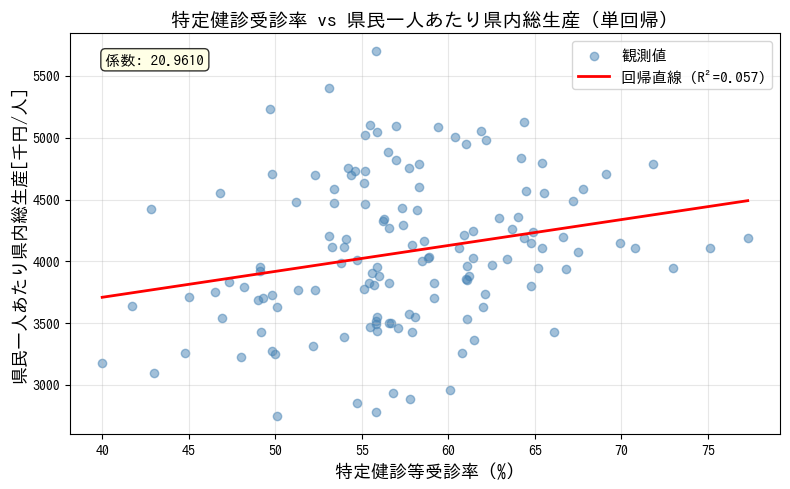


【単回帰結果】
  回帰係数: 20.9610
  p値: 0.0048  *** 有意 (1%)
  R²: 0.0569
                            OLS Regression Results                            
Dep. Variable:     県民一人あたり県内総生産[千円/人]   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     8.207
Date:                Sun, 28 Jun 2026   Prob (F-statistic):            0.00483
Time:                        02:12:38   Log-Likelihood:                -1073.1
No. Observations:                 138   AIC:                             2150.
Df Residuals:                     136   BIC:                             2156.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [2]:
## 単回帰：特定健診等 → 県民一人あたり県内総生産
X_simple = sm.add_constant(df_without_tokyo['特定健診等'])
y = df_without_tokyo['県民一人あたり県内総生産[千円/人]']

model_simple = sm.OLS(y, X_simple).fit()


## 散布図（単回帰）
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_without_tokyo['特定健診等'], df_without_tokyo['県民一人あたり県内総生産[千円/人]'], alpha=0.5, color='steelblue', label='観測値')

x_range = np.linspace(df_without_tokyo['特定健診等'].min(), df_without_tokyo['特定健診等'].max(), 100)
x_pred = sm.add_constant(x_range)
y_pred = model_simple.predict(x_pred)
ax.plot(x_range, y_pred, color='red', linewidth=2, label=f'回帰直線 (R²={model_simple.rsquared:.3f})')

ax.set_xlabel('特定健診等受診率 (%)', fontsize=13)
ax.set_ylabel('県民一人あたり県内総生産[千円/人]', fontsize=13)
ax.set_title('特定健診受診率 vs 県民一人あたり県内総生産（単回帰）', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

coef = model_simple.params['特定健診等']
pval = model_simple.pvalues['特定健診等']
# ax.text(0.05, 0.95, f'係数: {coef:.4f}  p値: {pval:.4f}',
#         transform=ax.transAxes, fontsize=11, verticalalignment='top',
#         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.text(0.05, 0.95, f'係数: {coef:.4f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n【単回帰結果】")
print(f"  回帰係数: {coef:.4f}")
print(f"  p値: {pval:.4f}  {'*** 有意 (1%)' if pval<0.01 else '** 有意 (5%)' if pval<0.05 else '* 有意 (10%)' if pval<0.1 else '有意でない'}")
print(f"  R²: {model_simple.rsquared:.4f}")

print(model_simple.summary())

## 一般化加法モデル（GAM）で、特定健診受診率と生産性の非線形な関係を確認する

【GAM結果】
  Explained deviance: 0.3278
  AIC: 3966.02
  有効自由度: 10.62
  選択された lambda: 1


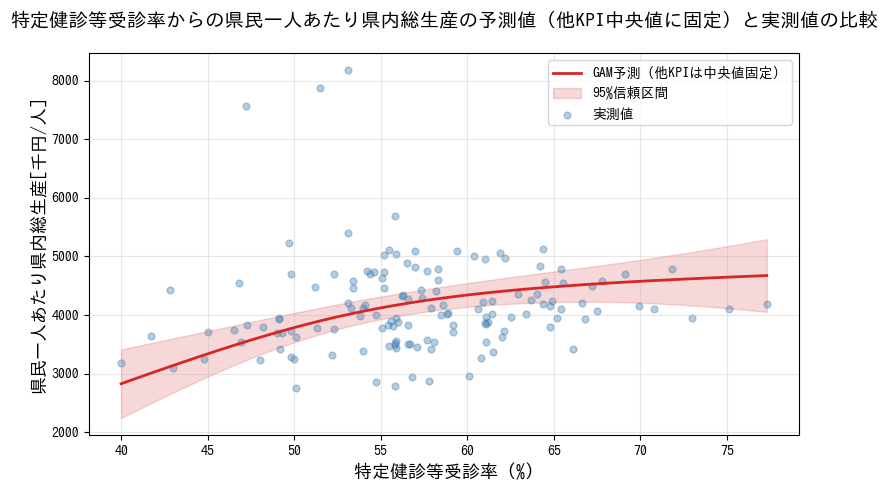


特定健診等以外を中央値に固定した予測値:
   特定健診等受診率(%)  予測 県民一人あたり県内総生産[千円/人]
0         49.1                3711.87
1         56.6                4203.73
2         65.4                4490.84


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csc_matrix, csr_matrix
from pygam import LinearGAM, s

# pygam 0.9.x は SciPy の疎行列 .A 属性を参照するため、
# 新しい SciPy でも動くように互換プロパティを補います。
for sparse_cls in (csr_matrix, csc_matrix):
    if not hasattr(sparse_cls, 'A'):
        sparse_cls.A = property(lambda self: self.toarray())

gam_feature_cols = [
    '特定健診等',
    '特定保健指導',
    '受診勧奨',
    '後発医薬品',
    '対象者減少率',
]

gam_df = df[gam_feature_cols + ['県民一人あたり県内総生産[千円/人]']].dropna()
X_gam = gam_df[gam_feature_cols].to_numpy()
y_gam = gam_df['県民一人あたり県内総生産[千円/人]'].to_numpy()

terms = s(0, n_splines=6)
for i in range(1, len(gam_feature_cols)):
    terms += s(i, n_splines=6)

gam = LinearGAM(terms).gridsearch(
    X_gam,
    y_gam,
    lam=np.logspace(-3, 3, 7),
    progress=False,
)

pseudo_r2 = gam.statistics_['pseudo_r2']['explained_deviance']
print('【GAM結果】')
print(f"  Explained deviance: {pseudo_r2:.4f}")
print(f"  AIC: {gam.statistics_['AIC']:.2f}")
print(f"  有効自由度: {gam.statistics_['edof']:.2f}")
print(f"  選択された lambda: {np.asarray(gam.lam).ravel()[0]:.4g}")

# term=0（特定健診等）のグリッドを作成
XX = gam.generate_X_grid(term=0, n=100)

# 他のKPIを中央値に固定した「フル特徴量」グリッドを作成し、
# partial_dependence ではなく predict で絶対値スケールの予測曲線を得る
median_row = gam_df[gam_feature_cols].median().to_frame().T
XX_full = pd.concat([median_row] * len(XX), ignore_index=True)
XX_full['特定健診等'] = XX[:, 0]  # term=0 のグリッド値だけを差し替え

curve_pred = gam.predict(XX_full.to_numpy())
curve_ci = gam.confidence_intervals(XX_full.to_numpy(), width=0.95)
# --- 修正部分ここまで ---

fig, ax = plt.subplots(figsize=(8, 5))

# 予測カーブ（絶対値スケール、他のKPIは中央値固定）
ax.plot(XX[:, 0], curve_pred, color='#d62728', linewidth=2, label='GAM予測（他KPIは中央値固定）')
ax.fill_between(XX[:, 0], curve_ci[:, 0], curve_ci[:, 1], color='#d62728', alpha=0.18, label='95%信頼区間')

# 実測値（生のデータ点。他のKPIの値はバラバラなので、カーブからは外れて散らばる）
ax.scatter(
    gam_df['特定健診等'],
    gam_df['県民一人あたり県内総生産[千円/人]'],
    color='steelblue',
    alpha=0.4,
    s=24,
    label='実測値',
)

ax.set_xlabel('特定健診等受診率 (%)', fontsize=13)
ax.set_ylabel('県民一人あたり県内総生産[千円/人]', fontsize=13)
ax.set_title('特定健診等受診率からの県民一人あたり県内総生産の予測値（他KPI中央値に固定）と実測値の比較\n', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 特定健診等の予測値を、観測範囲の下位・中央値・上位で比較します。
check_rates = np.percentile(gam_df['特定健診等'], [10, 50, 90])
check_X = pd.concat([median_row] * len(check_rates), ignore_index=True)
check_X['特定健診等'] = check_rates
check_pred = gam.predict(check_X.to_numpy())

print('\n特定健診等以外を中央値に固定した予測値:')
print(pd.DataFrame({
    '特定健診等受診率(%)': check_rates,
    '予測 県民一人あたり県内総生産[千円/人]': check_pred,
}).round(2))

【GAM結果】
  Explained deviance: 0.3468
  AIC: 3706.33
  有効自由度: 10.55
  選択された lambda: 1


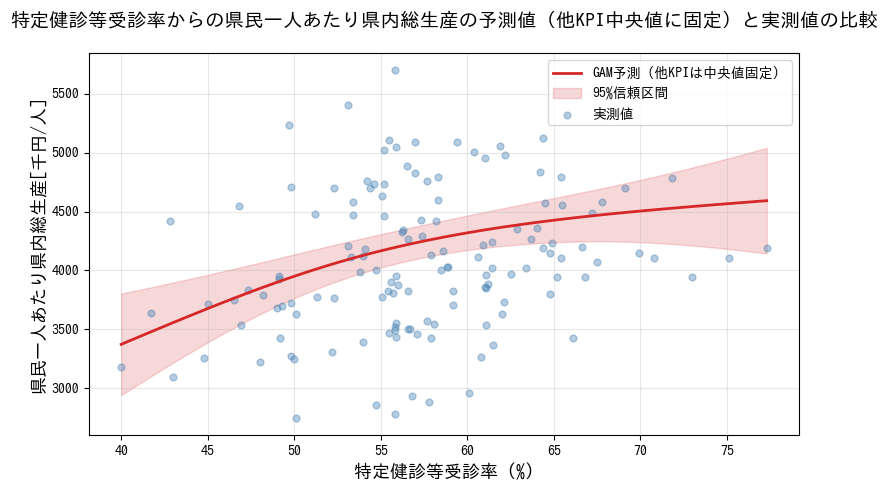


特定健診等以外を中央値に固定した予測値:
   特定健診等受診率(%)  予測 県民一人あたり県内総生産[千円/人]
0        49.10                3904.21
1        56.75                4225.85
2        65.43                4433.68


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csc_matrix, csr_matrix
from pygam import LinearGAM, s

# pygam 0.9.x は SciPy の疎行列 .A 属性を参照するため、
# 新しい SciPy でも動くように互換プロパティを補います。
for sparse_cls in (csr_matrix, csc_matrix):
    if not hasattr(sparse_cls, 'A'):
        sparse_cls.A = property(lambda self: self.toarray())

gam_feature_cols = [
    '特定健診等',
    '特定保健指導',
    '受診勧奨',
    '後発医薬品',
    '対象者減少率',
]

df_without_tokyo = df[df['支部名'] != '東京'].copy()
gam_df = df_without_tokyo[gam_feature_cols + ['県民一人あたり県内総生産[千円/人]']].dropna()
X_gam = gam_df[gam_feature_cols].to_numpy()
y_gam = gam_df['県民一人あたり県内総生産[千円/人]'].to_numpy()

terms = s(0, n_splines=6)
for i in range(1, len(gam_feature_cols)):
    terms += s(i, n_splines=6)

gam = LinearGAM(terms).gridsearch(
    X_gam,
    y_gam,
    lam=np.logspace(-3, 3, 7),
    progress=False,
)

pseudo_r2 = gam.statistics_['pseudo_r2']['explained_deviance']
print('【GAM結果】')
print(f"  Explained deviance: {pseudo_r2:.4f}")
print(f"  AIC: {gam.statistics_['AIC']:.2f}")
print(f"  有効自由度: {gam.statistics_['edof']:.2f}")
print(f"  選択された lambda: {np.asarray(gam.lam).ravel()[0]:.4g}")

# term=0（特定健診等）のグリッドを作成
XX = gam.generate_X_grid(term=0, n=100)

# 他のKPIを中央値に固定した「フル特徴量」グリッドを作成し、
# partial_dependence ではなく predict で絶対値スケールの予測曲線を得る
median_row = gam_df[gam_feature_cols].median().to_frame().T
XX_full = pd.concat([median_row] * len(XX), ignore_index=True)
XX_full['特定健診等'] = XX[:, 0]  # term=0 のグリッド値だけを差し替え

curve_pred = gam.predict(XX_full.to_numpy())
curve_ci = gam.confidence_intervals(XX_full.to_numpy(), width=0.95)
# --- 修正部分ここまで ---

fig, ax = plt.subplots(figsize=(8, 5))

# 予測カーブ（絶対値スケール、他のKPIは中央値固定）
ax.plot(XX[:, 0], curve_pred, color='#d62728', linewidth=2, label='GAM予測（他KPIは中央値固定）')
ax.fill_between(XX[:, 0], curve_ci[:, 0], curve_ci[:, 1], color='#d62728', alpha=0.18, label='95%信頼区間')

# 実測値（生のデータ点。他のKPIの値はバラバラなので、カーブからは外れて散らばる）
ax.scatter(
    gam_df['特定健診等'],
    gam_df['県民一人あたり県内総生産[千円/人]'],
    color='steelblue',
    alpha=0.4,
    s=24,
    label='実測値',
)

ax.set_xlabel('特定健診等受診率 (%)', fontsize=13)
ax.set_ylabel('県民一人あたり県内総生産[千円/人]', fontsize=13)
ax.set_title('特定健診等受診率からの県民一人あたり県内総生産の予測値（他KPI中央値に固定）と実測値の比較\n', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 特定健診等の予測値を、観測範囲の下位・中央値・上位で比較します。
check_rates = np.percentile(gam_df['特定健診等'], [10, 50, 90])
check_X = pd.concat([median_row] * len(check_rates), ignore_index=True)
check_X['特定健診等'] = check_rates
check_pred = gam.predict(check_X.to_numpy())

print('\n特定健診等以外を中央値に固定した予測値:')
print(pd.DataFrame({
    '特定健診等受診率(%)': check_rates,
    '予測 県民一人あたり県内総生産[千円/人]': check_pred,
}).round(2))